# Stacked Charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("survey-data.csv")
df.head(5)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


# Stacked Chart for Composition of Job Satisfaction Across Age Groups
1. Stacked Chart of Median JobSatPoints_6 and JobSatPoints_7 for Different Age Groups
Visualize the composition of job satisfaction scores (JobSatPoints_6 and JobSatPoints_7) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.

In [3]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [4]:
df['JobSatPoints_6'].value_counts()

JobSatPoints_6
0.00     7912
20.00    4352
10.00    3328
30.00    2482
15.00    1466
         ... 
73.00       1
6.25        1
57.00       1
61.00       1
63.00       1
Name: count, Length: 93, dtype: int64

In [5]:
df['JobSatPoints_7'].value_counts()

JobSatPoints_7
0.0     8119
20.0    4233
10.0    3934
30.0    2080
15.0    1601
        ... 
81.0       1
73.0       1
94.0       1
61.0       1
36.0       1
Name: count, Length: 91, dtype: int64

In [7]:
df_grouped = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

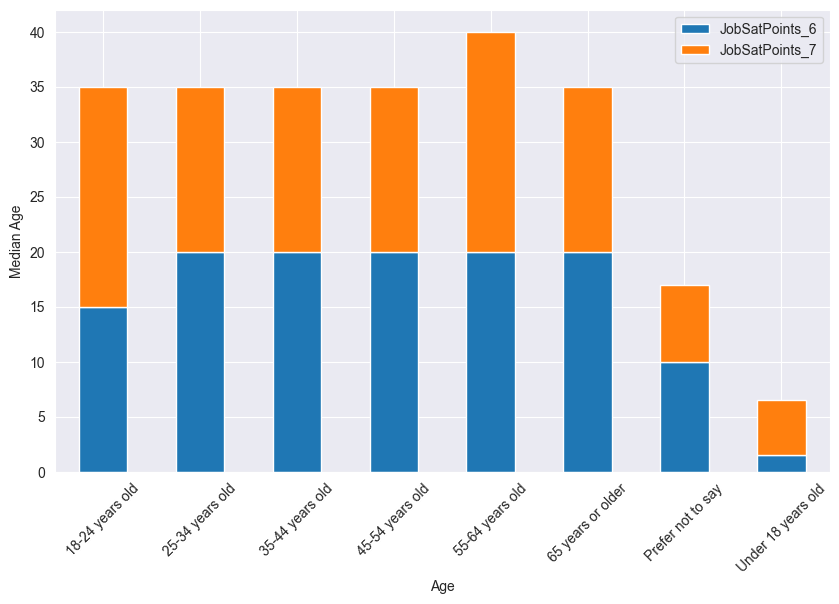

In [12]:
df_grouped.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Age')
plt.ylabel('Median Age')
plt.xticks(rotation=45)
plt.show()

# Stacked Chart for Technology Adoption by Employment Type

In [15]:
df['PlatformAdmired'].value_counts()

PlatformAdmired
Amazon Web Services (AWS)                                                                                                                                                                                                                                                                            6240
Microsoft Azure                                                                                                                                                                                                                                                                                      3572
Google Cloud                                                                                                                                                                                                                                                                                         1692
Amazon Web Services (AWS);Microsoft Azure                                                 

In [27]:
def categorize_employment(employment):
    if 'full-time' in employment.lower():
        return 'Full-time'
    elif 'freelance' in employment.lower():
        return 'Freelance'
    else:
        return 'Other'

In [29]:
df_emp = df[['Employment', 'PlatformAdmired']].copy()
df_emp = df_emp.dropna(subset=['PlatformAdmired', 'Employment'])
df_emp['PlatformAdmired'] = df_emp['PlatformAdmired'].str.split(';')
df_emp_exploded = df_emp.explode('PlatformAdmired')
df_emp_exploded['EmploymentCategory'] = df_emp_exploded['Employment'].apply(categorize_employment)
platform_counts = df_emp_exploded.groupby(['PlatformAdmired', 'EmploymentCategory']).size().unstack(fill_value=0)

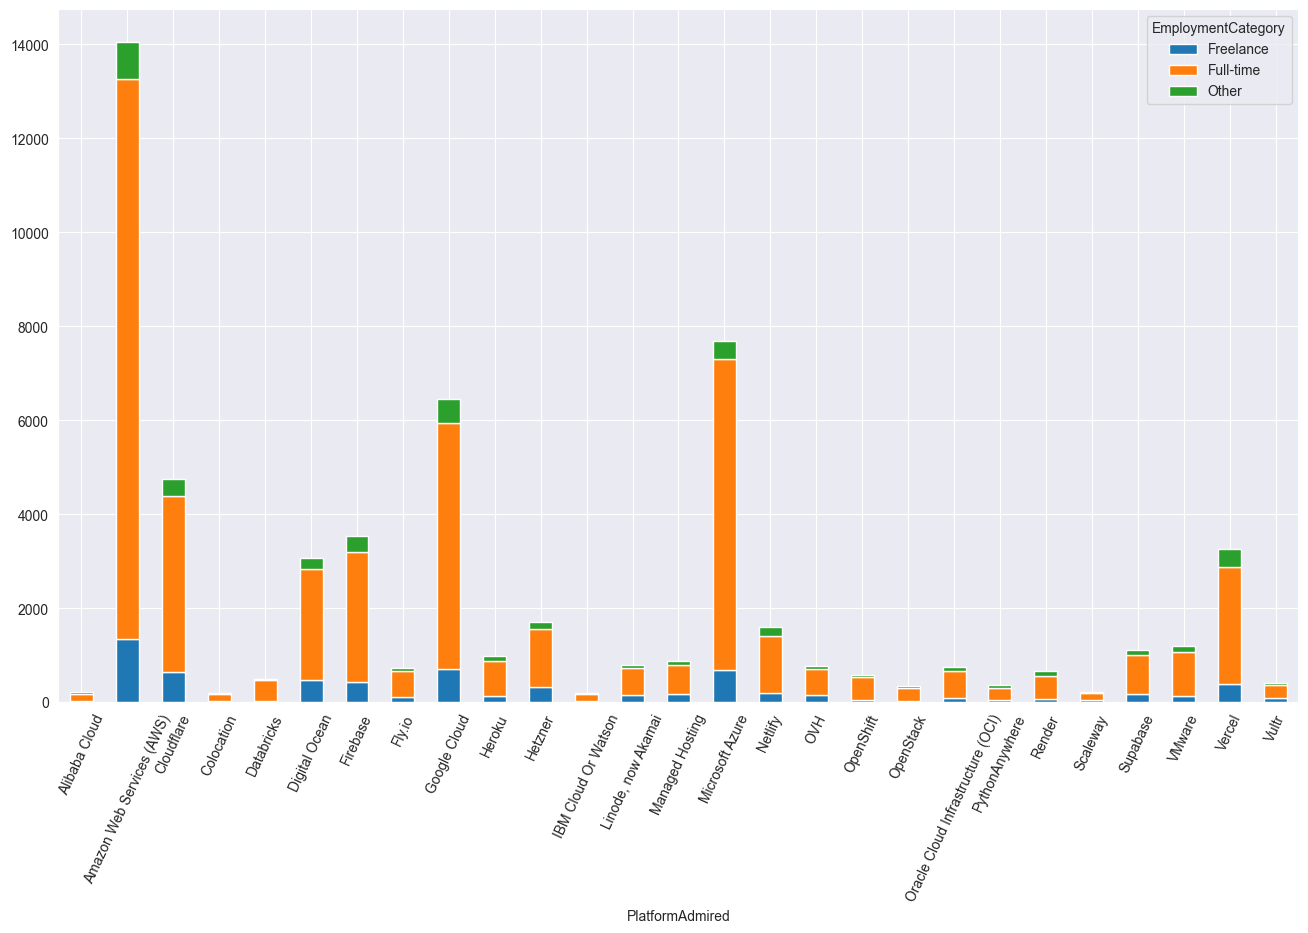

In [32]:
platform_counts.plot(kind='bar', stacked=True, figsize=(16,9))
plt.xticks(rotation=65)
plt.show()

# Another stack chart